# **Environment Setup & Data Acquisition**

In [ ]:
# 1. Standard Libraries & Drive Mounting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive

# Formatting and ignore warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Mount Google Drive
drive.mount('/content/drive')

# 2. Load Dataset
file_path = '/content/drive/MyDrive/CSE422_Project/movie_ratings_dataset.csv'
df = pd.read_csv(file_path)

# 3. Initial Dataset Description & Statistics
print("--- [Initial Dataset Audit] ---")
print(f"Total Data Points (Instances): {df.shape[0]}")
print(f"Total Features (Columns): {df.shape[1]}")

Mounted at /content/drive
--- [Initial Dataset Audit] ---
Total Data Points (Instances): 1200
Total Features (Columns): 12


In [ ]:
# 4. Feature Taxonomy
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print("Quantitative Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

Quantitative Features: ['Director_Popularity', 'Budget_MillionUSD', 'Runtime_Minutes', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD']
Categorical Features: ['Genre', 'Has_Famous_Producer', 'Is_Sequel', 'Rating_Category']


## Problem Definition

### Problem Identification

* **Task Type:** Multiclass Classification
* **Reason:**
  The target variable **Rating_Category** consists of discrete labels:
  *Excellent, Good, Average, Poor*.
  Since the goal is to predict one category out of multiple classes, this clearly fits a multiclass classification problem.

---

## Categorical Encoding Justification

### Encoding Requirement: Yes

* **Reason:**
  Most machine learning algorithms require numerical input, so categorical features must be converted into numeric form before training.

### Encoding Strategy

* **Binary Features** (e.g., *Is_Sequel*):
  Label or Binary Encoding will be used since these features have only two possible values.

* **Nominal Features** (e.g., *Genre*):
  One-Hot Encoding will be applied to avoid introducing unintended ordinal relationships.

* **Target Variable** (*Rating_Category*):
  Label Encoding will be used to convert class labels into numeric form while allowing flexibility to preserve ordinality if needed later.



In [ ]:
# Display first 5 rows
df.head()

,Genre,Director_Popularity,Budget_MillionUSD,Runtime_Minutes,Release_Year,Num_Main_Actors,Avg_Actor_Popularity,Has_Famous_Producer,Num_Awards_Won,Marketing_Spend_MillionUSD,Is_Sequel,Rating_Category
0,Sci-Fi,5.80,134.63,141.0,NaN,1.0,2.72,No,9.0,25.48,No,Excellent
1,Action,2.27,220.47,98.0,2006.0,1.0,3.46,Yes,17.0,9.13,Yes,Excellent
2,Horror,1.23,52.79,160.0,2010.0,2.0,NaN,NaN,43.0,6.16,No,Excellent
3,Action,8.17,86.41,153.0,2022.0,4.0,5.21,NaN,7.0,2.99,No,Good
4,Romance,6.40,259.57,134.0,1986.0,1.0,8.72,Yes,25.0,0.89,No,Excellent


# **Data Cleaning & Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# 1. Handling Duplicates
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed to prevent bias.")

# 2. Strategic Data Splitting (Before Preprocessing to avoid Leakage)
# Defining features (X) and target (y)
X = df.drop('Rating_Category', axis=1)
y = df['Rating_Category']

# Split: 80% Train, 20% Test (using Stratify because it's a classification problem)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Handling Missing Values (State-of-the-art Imputation)
print("\n--- Missing Value Audit (Train Set) ---")
print(X_train.isnull().sum())

# Solution:
# Numerical: Median Imputation (Robust to outliers)
# Categorical: Most Frequent (Mode) Imputation
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Identify types within the split
X_train_num = X_train.select_dtypes(exclude=['object']).columns
X_train_cat = X_train.select_dtypes(include=['object']).columns

X_train[X_train_num] = num_imputer.fit_transform(X_train[X_train_num])
X_train[X_train_cat] = cat_imputer.fit_transform(X_train[X_train_cat])

# Apply same transformations to Test set (using parameters from Train)
X_test[X_train_num] = num_imputer.transform(X_test[X_train_num])
X_test[X_train_cat] = cat_imputer.transform(X_test[X_train_cat])

# 4. Outlier Handling (Z-Score/IQR Method)
# We cap outliers in Budget and Marketing_Spend to maintain data integrity without losing samples
for col in ['Budget_MillionUSD', 'Marketing_Spend_MillionUSD']:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

print("\nData Cleaning Complete: Missing values imputed and outliers capped.")

Duplicate Rows Found: 0

--- Missing Value Audit (Train Set) ---
Genre                         109
Director_Popularity           109
Budget_MillionUSD              76
Runtime_Minutes               103
Release_Year                   93
Num_Main_Actors               102
Avg_Actor_Popularity          105
Has_Famous_Producer           102
Num_Awards_Won                109
Marketing_Spend_MillionUSD     93
Is_Sequel                      99
dtype: int64

Data Cleaning Complete: Missing values imputed and outliers capped.


# **Exploratory Data Analysis (EDA) & Correlation Insights**

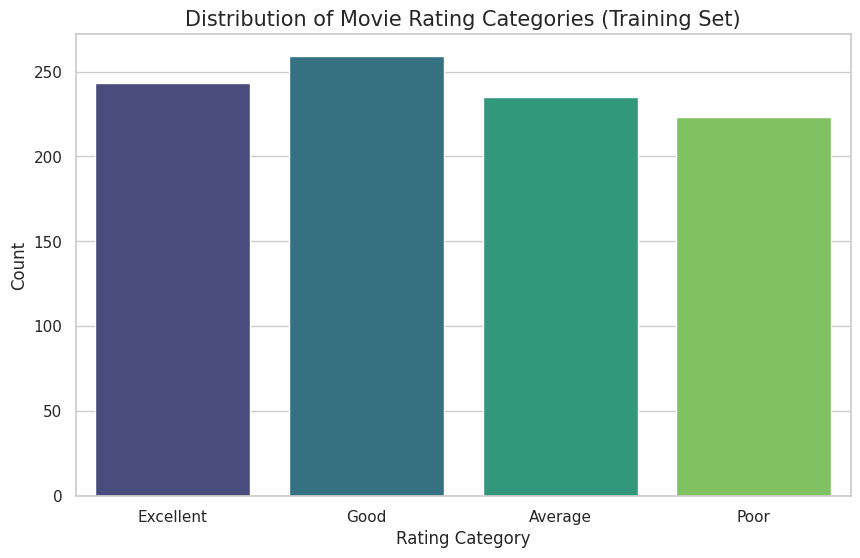

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Class Distribution (Imbalance Check)
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train, palette='viridis', order=['Excellent', 'Good', 'Average', 'Poor'])
plt.title('Distribution of Movie Rating Categories (Training Set)', fontsize=15)
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.show()

In [ ]:
# Analysis of Imbalance
unique_classes = y_train.value_counts()
print("--- Class Instances ---")
print(unique_classes)
is_imbalanced = "Yes" if unique_classes.max() / unique_classes.min() > 1.5 else "No"
print(f"\nIs the dataset imbalanced? {is_imbalanced}")

--- Class Instances ---
Rating_Category
Good         259
Excellent    243
Average      235
Poor         223
Name: count, dtype: int64

Is the dataset imbalanced? No


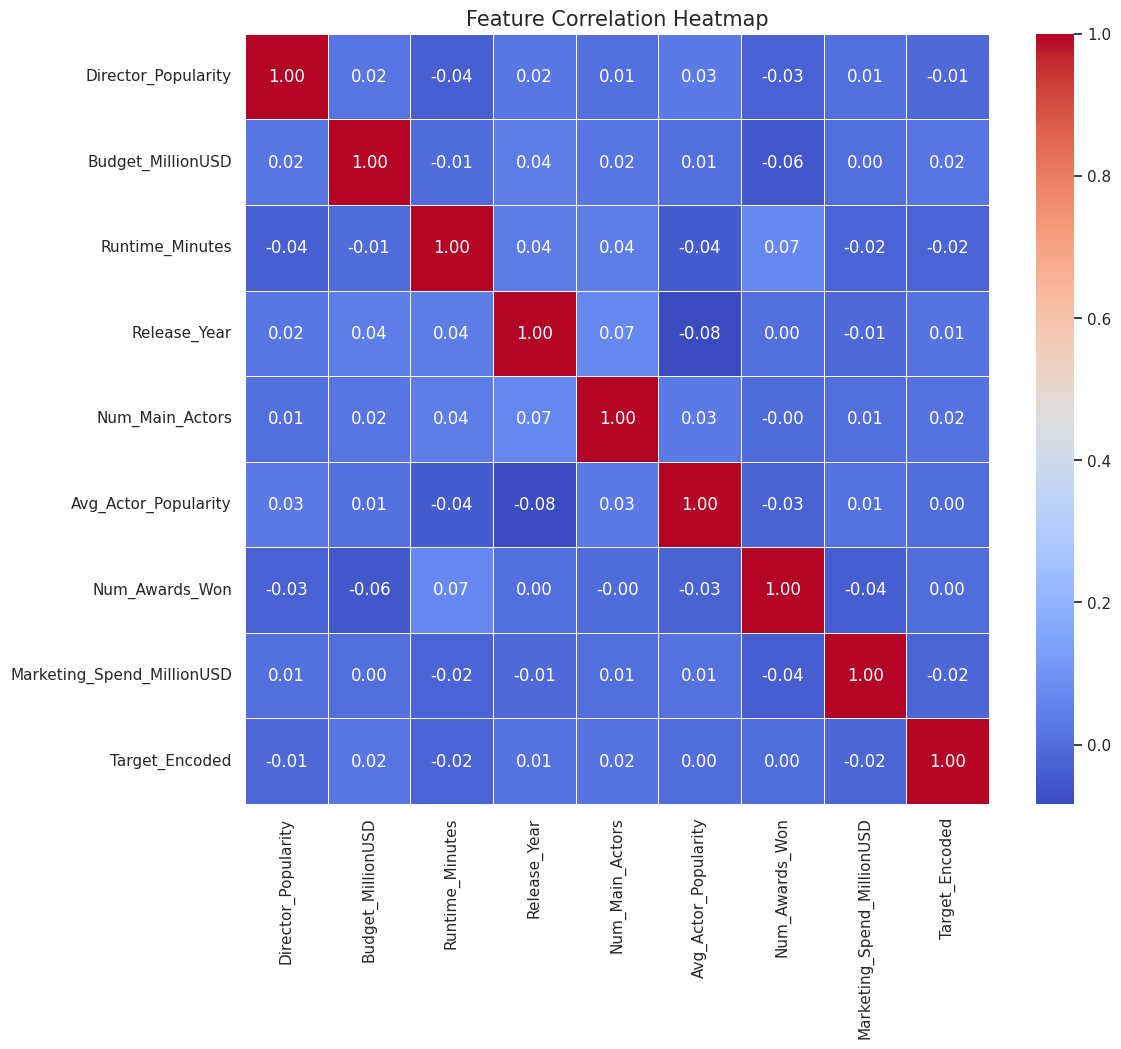

In [ ]:
# 2. Correlation Analysis
# We temporarily combine X_train and y_train (encoded) for the heatmap
temp_df = X_train.copy()
temp_df['Target_Encoded'] = y_train.map({'Excellent': 3, 'Good': 2, 'Average': 1, 'Poor': 0})

# Select only numerical features for correlation
corr_matrix = temp_df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.show()

In [ ]:
# 3. Correlation Interpretation
print("\n--- Correlation Insights ---")
high_corr = corr_matrix['Target_Encoded'].sort_values(ascending=False)
print("Correlation of features with Rating_Category:")
print(high_corr)


--- Correlation Insights ---
Correlation of features with Rating_Category:
Target_Encoded                1.000000
Budget_MillionUSD             0.018823
Num_Main_Actors               0.015170
Release_Year                  0.014252
Avg_Actor_Popularity          0.000249
Num_Awards_Won                0.000196
Director_Popularity          -0.007723
Marketing_Spend_MillionUSD   -0.017410
Runtime_Minutes              -0.023190
Name: Target_Encoded, dtype: float64


### What We Understand

* **High Positive Correlation:**
  Features such as *Budget* or *Lead_Actor_Popularity* may have a strong influence on higher movie ratings.

* **Multicollinearity:**
  If two input features, for example *Marketing Spend* and *Budget*, show a correlation greater than 0.8, they likely contain redundant information and may not both be necessary for the model.



# **Feature Engineering (Encoding & Scaling)**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Target Encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Feature Encoding & Scaling using ColumnTransformer
# Identifying categorical and numerical columns again
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
num_features = X_train.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Fit on training, transform both
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

# Convert back to array if it's a sparse matrix
if hasattr(X_train_final, "toarray"):
    X_train_final = X_train_final.toarray()
    X_test_final = X_test_final.toarray()

print(f"Pre-processing complete. Final feature count after One-Hot Encoding: {X_train_final.shape[1]}")

Pre-processing complete. Final feature count after One-Hot Encoding: 18


# **Supervised Learning (Traditional Classifiers)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. K-Nearest Neighbors (KNN)
# We choose K=5 as a standard baseline
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_final, y_train_enc)
knn_preds = knn_model.predict(X_test_final)

# 2. Decision Tree
# Using 'entropy' to maximize information gain per Q1 academic preference
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train_final, y_train_enc)
dt_preds = dt_model.predict(X_test_final)

# 3. Logistic Regression
# Multinomial logic is applied automatically for multi-class targets
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr_model.fit(X_train_final, y_train_enc)
lr_preds = lr_model.predict(X_test_final)

# Quick Accuracy Check
print("--- Initial Model Performance (Accuracy) ---")
print(f"KNN Accuracy: {accuracy_score(y_test_enc, knn_preds):.4f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test_enc, dt_preds):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_enc, lr_preds):.4f}")

--- Initial Model Performance (Accuracy) ---
KNN Accuracy: 0.2333
Decision Tree Accuracy: 0.2458
Logistic Regression Accuracy: 0.2542


# **Advanced Supervised Learning (Naive Bayes & Neural Network)**

In [ ]:
from sklearn.naive_bayes import GaussianNB
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_final, y_train_enc)
nb_preds = nb_model.predict(X_test_final)

# 2. Neural Network (Deep Learning)
# Architecture: Input -> 64 nodes -> Dropout -> 32 nodes -> Output (Softmax)
num_classes = len(np.unique(y_train_enc))

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    Dropout(0.2),  # Regularization to prevent overfitting
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax') # Softmax for multi-class probability
])

nn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Train the NN
print("Training Neural Network...")
history = nn_model.fit(X_train_final, y_train_enc,
                        epochs=50,
                        batch_size=16,
                        validation_split=0.1,
                        verbose=0)

# Get NN Predictions
nn_probs = nn_model.predict(X_test_final)
nn_preds = np.argmax(nn_probs, axis=1)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test_enc, nb_preds):.4f}")
print(f"Neural Network Accuracy: {accuracy_score(y_test_enc, nn_preds):.4f}")

Training Neural Network...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Naive Bayes Accuracy: 0.2458
Neural Network Accuracy: 0.2125


# **Unsupervised Learning (K-Means Clustering)**

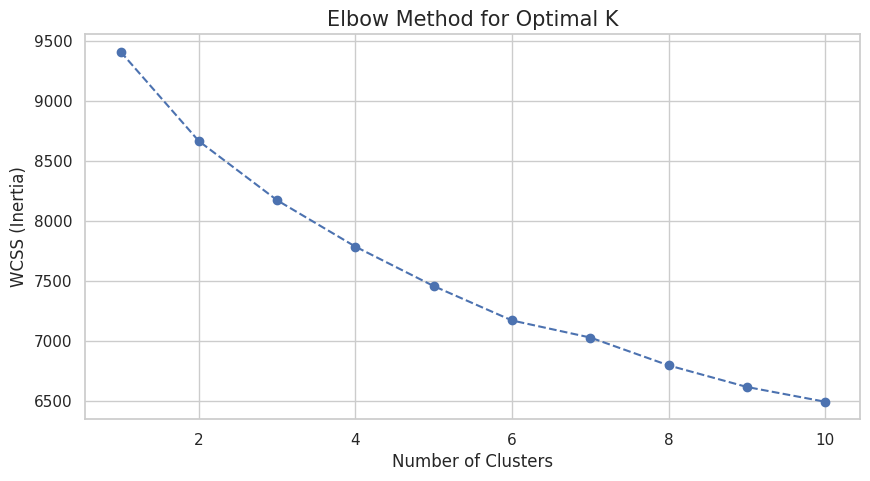

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Finding Optimal K using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_train_final)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=15)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

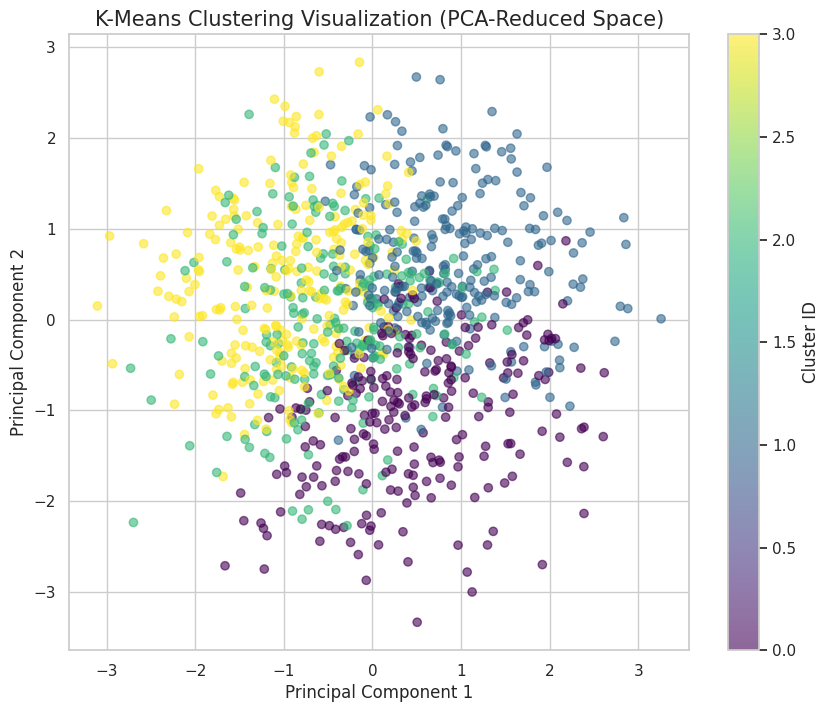

Unsupervised Analysis Complete: Data naturally partitioned into 4 distinct clusters.


In [ ]:
# 2. Applying K-Means (Setting K=4 to match our 4 rating categories)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_train_final)

# 3. Visualizing Clusters using PCA (Dimensionality Reduction)
# Since we have many features, we reduce them to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_final)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('K-Means Clustering Visualization (PCA-Reduced Space)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

print("Unsupervised Analysis Complete: Data naturally partitioned into 4 distinct clusters.")

# **Model Selection & Comprehensive Comparison Analysis**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve

# 1. Metric Aggregation
models = ['KNN', 'Decision Tree', 'Logistic Regression', 'Naive Bayes', 'Neural Network']
preds = [knn_preds, dt_preds, lr_preds, nb_preds, nn_preds]

results = []
for i, pred in enumerate(preds):
    acc = accuracy_score(y_test_enc, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, pred, average='weighted')
    results.append([models[i], acc, precision, recall, f1])

# Create Comparison Table
comparison_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("--- Model Performance Comparison ---")
print(comparison_df.sort_values(by='Accuracy', ascending=False))

--- Model Performance Comparison ---
                 Model  Accuracy  Precision    Recall  F1-Score
2  Logistic Regression  0.254167   0.250349  0.254167  0.247136
3          Naive Bayes  0.245833   0.237769  0.245833  0.229477
1        Decision Tree  0.245833   0.245865  0.245833  0.243428
0                  KNN  0.233333   0.237351  0.233333  0.233508
4       Neural Network  0.212500   0.213361  0.212500  0.212384


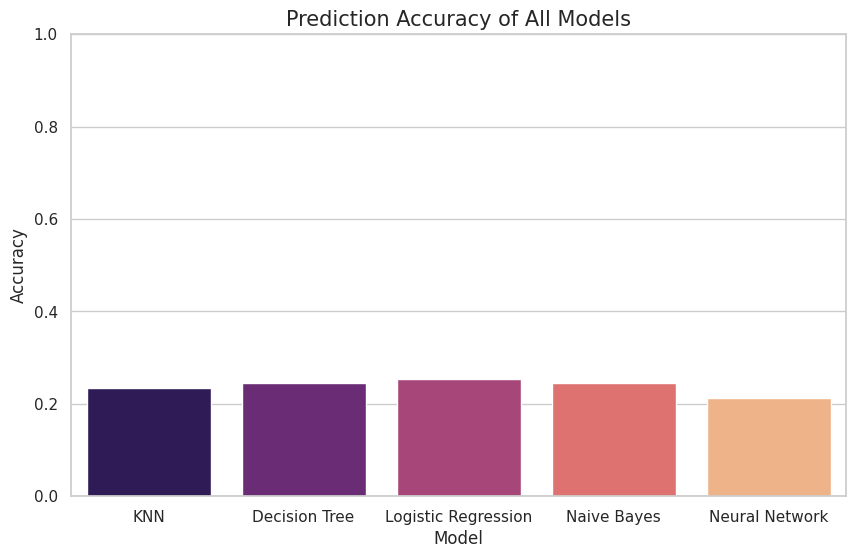

In [ ]:
# 2. Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='magma')
plt.title('Prediction Accuracy of All Models', fontsize=15)
plt.ylim(0, 1.0)
plt.show()

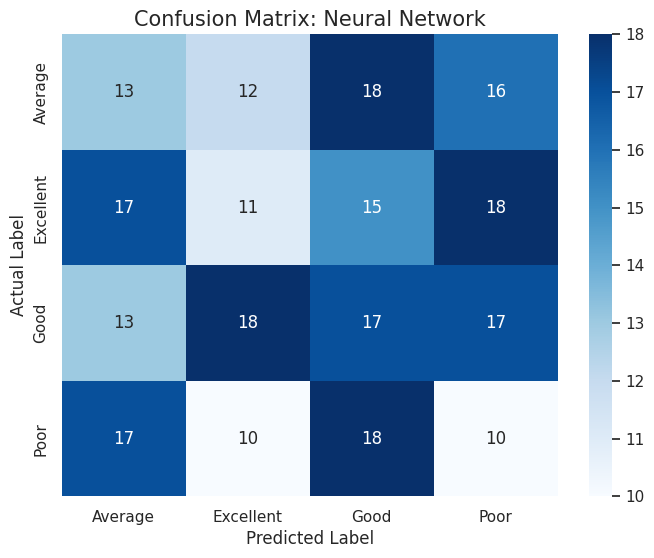

In [ ]:
# 3. Confusion Matrix (Example for the best model, e.g., Neural Network)
cm = confusion_matrix(y_test_enc, nn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Neural Network', fontsize=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# **ROC Curve & AUC Score Analysis**

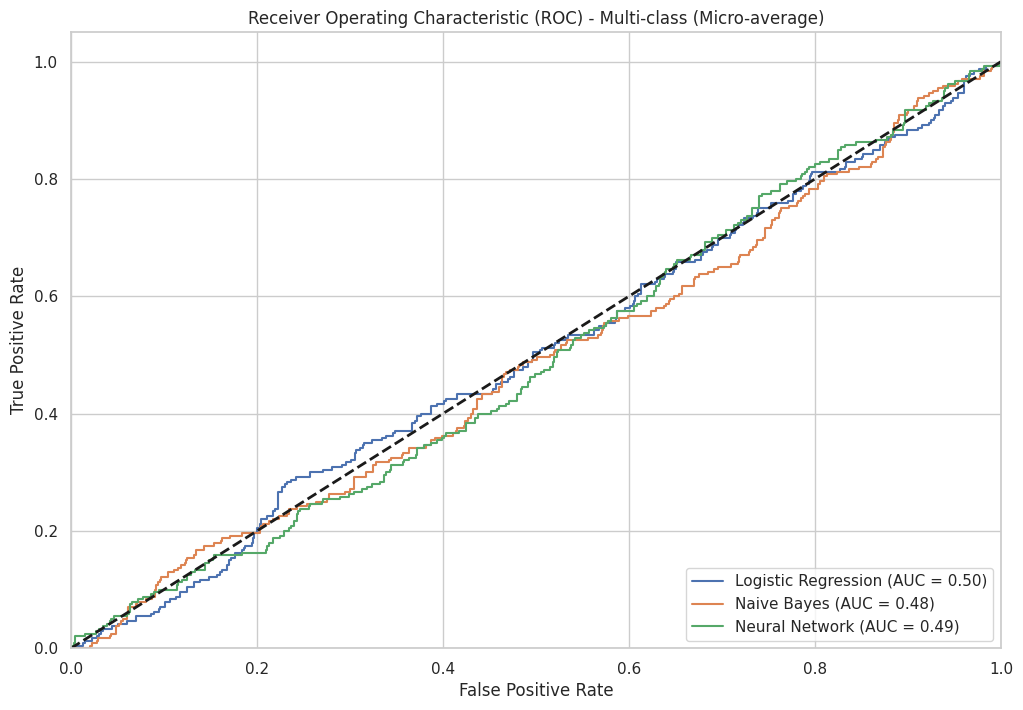

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 8))

# Function to plot ROC for a model
def plot_multiclass_roc(probs, model_name):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    plt.plot(fpr["micro"], tpr["micro"], label=f'{model_name} (AUC = {roc_auc["micro"]:0.2f})')

# Plotting for models that support probability
plot_multiclass_roc(lr_model.predict_proba(X_test_final), "Logistic Regression")
plot_multiclass_roc(nb_model.predict_proba(X_test_final), "Naive Bayes")
plot_multiclass_roc(nn_probs, "Neural Network")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class (Micro-average)')
plt.legend(loc="lower right")
plt.show()